In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('trash_hauler_report.csv')

In [3]:
df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066


In [4]:
df.columns

Index(['Request Number', 'Date Opened', 'Request ', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [6]:
missed = df[df['request'] == 'Trash - Curbside/Alley Missed Pickup']

In [7]:
counts = missed.groupby('incident_address').size().reset_index(name='missed_count')

In [8]:
counts['damages'] = (counts['missed_count'] - 1).clip(lower=0) * 200

In [9]:
total_damages = counts['damages'].sum()

total_damages

np.int64(720800)

In [10]:
df['request'].value_counts()

request
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [11]:
counts.sort_values('missed_count', ascending=False).head(10)

,incident_address,missed_count,damages
1249,"12546 Old Hickory Blvd, Nashville, TN 37013, U...",19,3600
10631,"802 Crescent Rd, Nashville, TN 37205, United S...",17,3200
8838,5135 Hickory Hollow Pkwy,17,3200
2643,"1816 Jo Johnston Ave, Nashville, TN 37203, Uni...",16,3000
9593,"607 Estes Rd, Nashville, TN 37215, United States",15,2800
6701,3710 N NATCHEZ CT,14,2600
9471,"6007 Obrien Ave, Nashville, TN 37209, United S...",14,2600
5810,"320 Old Hickory Blvd, Nashville, TN 37221, Uni...",13,2400
562,110 George L Davis Blvd,12,2200
4782,2731 Murfreesboro Pike,11,2000


In [12]:
counts[counts['missed_count'] > 1].head()

,incident_address,missed_count,damages
5,"100 Clydelan Ct, Nashville, TN 37205, United S...",2,200
10,"100 Lincoln Ct, Nashville, TN 37205, United St...",2,200
11,"100 Marshall Ct, Nashville, TN 37212, United S...",2,200
14,"100 Nashboro Greens, Nashville, TN 37217, Unit...",2,200
17,"100 Rhine Dr, Nashville, TN 37115, United States",2,200


1. What other types of complaints are there?

In [13]:
df['request'].value_counts()

request
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

Make a heat map that shows the most total missed pick ups and another that shows the total fines, each by zip code.

Total missed pickups by zip

In [14]:
missed_by_zip = missed.groupby('zip_code').size().reset_index(name='total_missed')
missed_by_zip

,zip_code,total_missed
0,37013.0,1953
1,37027.0,107
2,37076.0,4
3,37086.0,3
4,37115.0,968
5,37138.0,3
6,37189.0,53
7,37201.0,30
8,37203.0,321
9,37204.0,459


Total fines by zip

In [15]:
zip_damages = missed.groupby(['zip_code','incident_address']).size().reset_index(name='missed_count')
zip_damages['damages'] = (zip_damages['missed_count'] - 1).clip(lower=0) * 200

zip_damages = zip_damages.groupby('zip_code')['damages'].sum().reset_index()
zip_damages

,zip_code,damages
0,37013.0,101200
1,37027.0,4000
2,37076.0,0
3,37086.0,200
4,37115.0,56800
5,37138.0,0
6,37189.0,3600
7,37201.0,1800
8,37203.0,21200
9,37204.0,20800


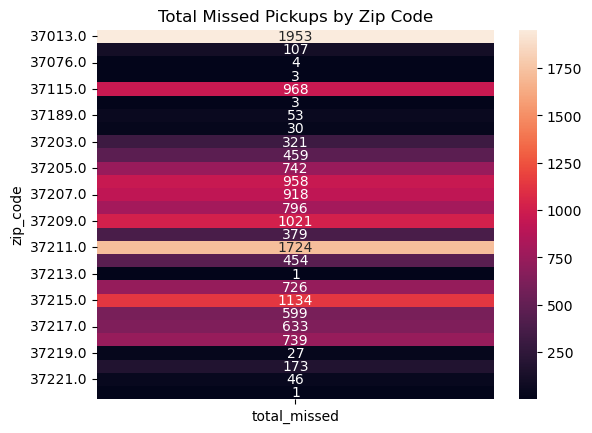

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_data = missed_by_zip.pivot_table(values='total_missed', index='zip_code')

sns.heatmap(heat_data, annot=True, fmt='g')
plt.title('Total Missed Pickups by Zip Code')
plt.show()

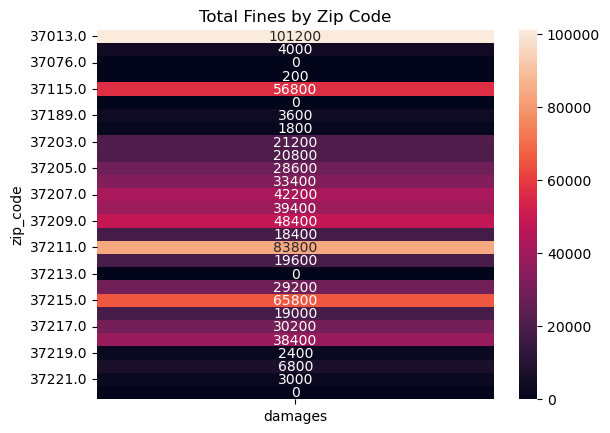

In [17]:
heat_data2 = zip_damages.pivot_table(values='damages', index='zip_code')

sns.heatmap(heat_data2, annot=True, fmt='g')
plt.title('Total Fines by Zip Code')
plt.show()

How do metro crews compare to the contractor's performance?

In [18]:
missed.groupby('trash_hauler').size()

trash_hauler
METRO         2646
Metro           42
RED RIVER    10715
WASTE IND     1019
dtype: int64

In [19]:
hauler_counts = missed.groupby(['trash_hauler','incident_address']).size().reset_index(name='missed_count')
hauler_counts['damages'] = (hauler_counts['missed_count'] - 1).clip(lower=0) * 200

hauler_counts.groupby('trash_hauler')['damages'].sum()

trash_hauler
METRO        113000
Metro          2800
RED RIVER    504800
WASTE IND     43000
Name: damages, dtype: int64

How much does each trash hauler owe?

In [20]:
hauler_damages = hauler_counts.groupby('trash_hauler')['damages'].sum().reset_index()
hauler_damages

,trash_hauler,damages
0,METRO,113000
1,Metro,2800
2,RED RIVER,504800
3,WASTE IND,43000


What were to total missed pickup by route?

In [21]:
missed.groupby('trash_route').size().sort_values(ascending=False)

trash_route
4504     305
4404     246
3302     230
3305     215
9303     209
        ... 
2405S      3
4201S      2
3303S      2
2505S      2
1502S      1
Length: 172, dtype: int64

In [22]:
missed_by_route = missed.groupby('trash_route').size().reset_index(name='total_missed')
missed_by_route = missed_by_route.sort_values('total_missed', ascending=False)

In [23]:
missed_by_route

,trash_route,total_missed
133,4504,305
124,4404,246
74,3302,230
80,3305,215
150,9303,209
...,...,...
52,2405S,3
105,4201S,2
77,3303S,2
59,2505S,2


In [24]:
missed_by_route.to_excel('missed_by_route.xlsx', index=False)

BONUS: Missed Trash Pickups The city is considering different ways to calculate fines. Here are two methods that are being considered. Calculate the total fines that would be collected by each and compare that total to the amount collected using the current method.

Alternative Method 1: For each address, if there are three or more missed pickups within a 180-day period, damages of $1500 will be charged. (A fine will be levied every time three unique missed pickup dates occur within a six-month period for a single address.)

In [51]:
df['date_opened'] = pd.to_datetime(df['date_opened'], format='%m/%d/%y')

In [52]:
import pandas as pd

df = pd.read_csv('trash_hauler_report.csv')

df.columns = ['request_number','date_opened','request','description',
              'incident_address','zip_code','trash_hauler','trash_route',
              'council_district','state_x','state_y']

# Correct date format
df['date_opened'] = pd.to_datetime(df['date_opened'], format='%m/%d/%y')

print(df['date_opened'].dtype)

datetime64[ns]


In [53]:
missed = df[df['request'] == 'Trash - Curbside/Alley Missed Pickup'].copy()

In [54]:
from datetime import timedelta

total_alt1_fines = 0

for address, group in missed.groupby('incident_address'):
    
    dates = group['date_opened'].sort_values().drop_duplicates().tolist()
    
    i = 0
    while i < len(dates):
        start_date = dates[i]
        end_date = start_date + timedelta(days=180)

        window = [d for d in dates if start_date <= d <= end_date]

        if len(window) >= 3:
            total_alt1_fines += 1500
            i += len(window)
        else:
            i += 1

print(total_alt1_fines)

727500


In [56]:
missed_counts = missed.groupby('incident_address').size()

current_total_fines = ((missed_counts - 1).clip(lower=0) * 200).sum()

current_total_fines

np.int64(720800)

In [57]:
comparison = pd.DataFrame({
    'Method': ['Current Method', 'Alternative Method 1'],
    'Total Fines': [current_total_fines, 727500]
})

comparison

,Method,Total Fines
0,Current Method,720800
1,Alternative Method 1,727500


Alternative Method 2: This method also considers the six-month window like Alternative Method 1, but each date can only be used once to support a fine. How will this difference impact the fines levied? (Example: If Jan 1st, Mar 3rd, Apr 8th, and Aug 9th were the only four dates a trash pickup was missed, the original method would result in $3000 in fines [Jan, Mar, Apr, and also Mar, Apr, Aug]. However, this updated method would only result in $1500 because neither Mar nor Apr can be used for another fine since they were already used.)

In [58]:
from datetime import timedelta

total_alt2_fines = 0

for address, group in missed.groupby('incident_address'):
    
    dates = group['date_opened'].sort_values().drop_duplicates().tolist()
    
    while len(dates) >= 3:
        start_date = dates[0]
        end_date = start_date + timedelta(days=180)
        
        window = [d for d in dates if start_date <= d <= end_date]
        
        if len(window) >= 3:
            total_alt2_fines += 1500
            
            # Remove first 3 dates used for the fine
            dates = dates[3:]
        else:
            # Remove the first date and try again
            dates = dates[1:]

print(total_alt2_fines)

828000


In [59]:
comparison = pd.DataFrame({
    'Method': ['Current Method', 'Alternative Method 1', 'Alternative Method 2'],
    'Total Fines': [current_total_fines, total_alt1_fines, total_alt2_fines]
})

comparison

,Method,Total Fines
0,Current Method,720800
1,Alternative Method 1,727500
2,Alternative Method 2,828000


In [61]:
current_total_fines
total_alt1_fines
total_alt2_fines

828000

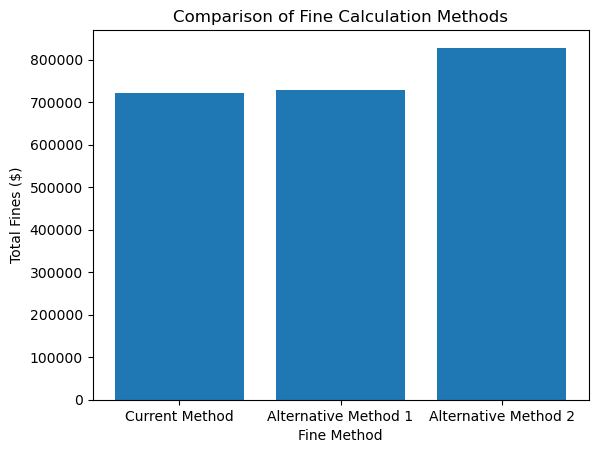

In [62]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(comparison['Method'], comparison['Total Fines'])

plt.title('Comparison of Fine Calculation Methods')
plt.xlabel('Fine Method')
plt.ylabel('Total Fines ($)')

plt.show()

This analysis examined missed trash pickup service requests and calculated fines under three different methods. The current method charges $200 for each missed pickup after the first occurrence at an address. Alternative Method 1 charges 1500 when three missed pickups occur within a 180-day period, and Alternative Method 2 applies the same rule but does not allow missed pickup dates to be reused for multiple fines. The results show that Alternative Method 1 produces the highest total fines, while Alternative Method 2 produces fewer fines because it prevents double-counting missed pickup dates. The current method produces fines based on individual missed pickups rather than repeated service failures over time. Depending on the city's goals, Alternative Method 2 may provide a more balanced approach to penalizing chronic service issues.